In [35]:
import pandas as pd
import io
from scipy.interpolate import griddata
import numpy as np
import re
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from pyhdf.SD import SD, SDC
from scipy.io import loadmat
from mpl_toolkits.mplot3d import Axes3D
from pyhdf.SD import SD, SDC
import matplotlib.pyplot as plt
from itertools import islice
import matplotlib.ticker as ticker

In [36]:
data = loadmat(r'C:\FINAL_SUMMER_PROJ\TPU_TEST_FILES\WIND_LOW_RISE_NO_ISO\Cp_ts_219619_deg000.mat')


# 1. Flip the location data so it's a table
loc_matrix = data['Location_of_measured_points']
loc_df = pd.DataFrame(loc_matrix.T, columns=['X', 'Y', 'Point_No', 'Face_No'])


pressure_df = pd.DataFrame(data['Wind_pressure_coefficients'])

print(f"Total Taps: {len(loc_df)}")
print(f"Total Timesteps: {len(pressure_df)}")

Total Taps: 344
Total Timesteps: 14063


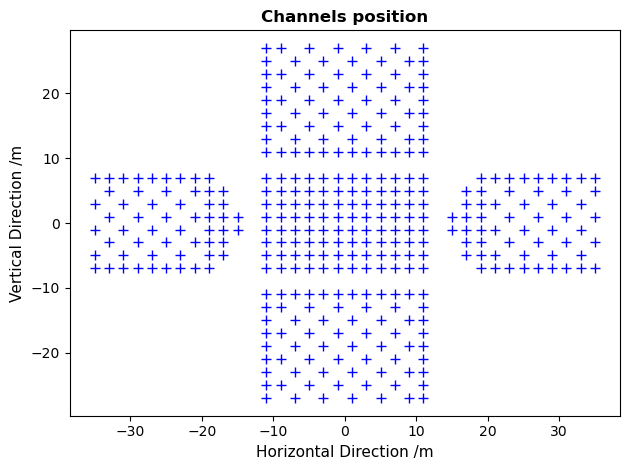

In [37]:
def get_channel_plot(loc_df):
    x = loc_df['X']
    y = loc_df['Y']


    plt.scatter(loc_df['X'], loc_df['Y'], marker='+', color='blue', s=50, linewidth=1)

    plt.title("Channels position", fontweight='bold', fontsize=12)
    plt.xlabel("Horizontal Direction /m", fontsize=11)
    plt.ylabel("Vertical Direction /m", fontsize=11)

    # Show the fully reconstructed plot
    plt.tight_layout()
    plt.show()

get_channel_plot(loc_df)

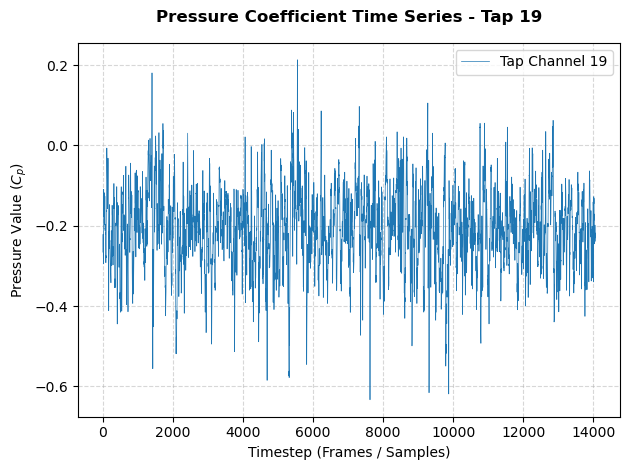

In [38]:
def view_all_steps(pressure_df, tap_no):
    tap_idx = int(tap_no)

    pressure_at_tap = pressure_df[tap_idx]


    plt.plot(
        pressure_at_tap.index, 
        pressure_at_tap.values, 
        color='#1f77b4', 
        linewidth=0.5, 
        label=f'Tap Channel {tap_no}'
    )

    
    plt.title(f'Pressure Coefficient Time Series - Tap {tap_no}', fontsize=12, fontweight='bold', pad=15)
    plt.xlabel('Timestep (Frames / Samples)', fontsize=10)
    plt.ylabel('Pressure Value ($C_p$)', fontsize=10)

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')

    plt.tight_layout()

    plt.show()

view_all_steps(pressure_df, 19)

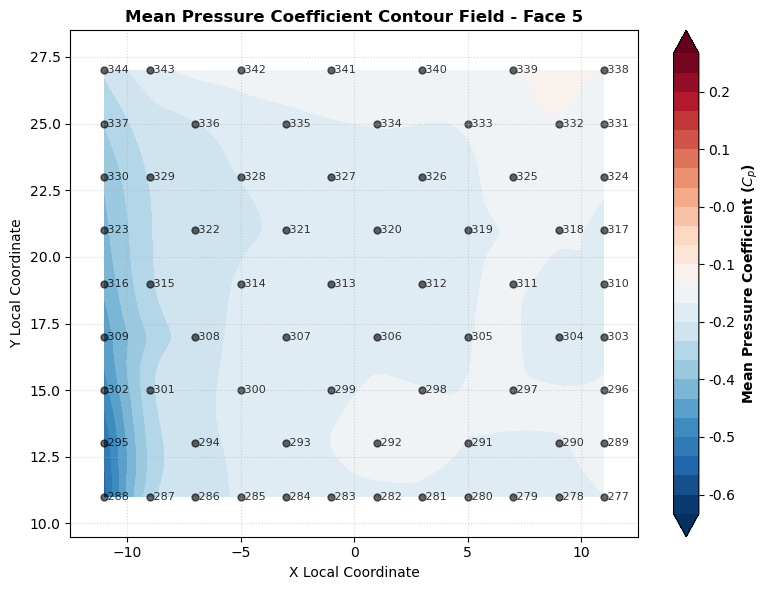

In [39]:
def mean_cp_contour(pressure_df, loc_df, face_id):
    """
    Generates a dedicated mean Cp contour plot for one explicitly chosen building face.
    
    Parameters:
    - loc_df: DataFrame containing the raw tap coordinates ('X', 'Y', 'Point_No', 'Face_No')
    - pressure_df: DataFrame containing the time-series wind pressure coefficients
    - face_id: Integer (e.g., 1, 2, 5) targeting the specific face to visualize
    """
    # 1. Calculate the mean pressure coefficient (Cp) for each channel
    mean_cp_series = pressure_df.mean(axis=0)
    mean_cp_df = mean_cp_series.reset_index()
    mean_cp_df.columns = ['Tap no.', 'mean_cp']

    # 2. Map the means back to the coordinates
    total_active_channels = pressure_df.shape[1]
    working_df = loc_df.head(total_active_channels).copy()
    working_df['mean_cp'] = mean_cp_df['mean_cp'].values[:total_active_channels]

    # Get the global min and max Cp across the entire building to keep color scales consistent
    vmin = working_df['mean_cp'].min()
    vmax = working_df['mean_cp'].max()
    levels = np.linspace(vmin, vmax, 25)

    # 3. Isolate the data specifically for the requested face
    face_data = working_df[working_df['Face_No'] == face_id].copy()
    
    if face_data.empty:
        print(f"❌ Error: Face {face_id} was not found in this dataset or contains no active data channels.")
        return

    # Remove any duplicate tap positions within this face zone
    face_data = face_data.drop_duplicates(subset=['X', 'Y'])
    
    # We need at least 3 unique tap coordinates to calculate a 2D surface field mesh
    if len(face_data) < 3:
        print(f"⚠️ Face {face_id} has only {len(face_data)} unique points. Switching to 'nearest' mapping grid fallback.")
        method_choice = 'nearest'
    else:
        method_choice = 'cubic'

    x = face_data['X'].values
    y = face_data['Y'].values
    z = face_data['mean_cp'].values

    # 4. Handle Flat 1D Profiles (e.g., if a wall face only has one straight row of sensors)
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    
    # Nudge the mesh limits if coordinates are perfectly aligned to prevent QhullError crashes
    if x_min == x_max:
        x_min -= 0.01
        x_max += 0.01
        method_choice = 'nearest'  # Force nearest neighbor if geometrically flat
    if y_min == y_max:
        y_min -= 0.01
        y_max += 0.01
        method_choice = 'nearest'

    # 5. Create a dense coordinate mesh grid for this isolated face
    grid_x, grid_y = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    # 6. Interpolate values locally onto the mesh grid
    try:
        grid_z = griddata((x, y), z, (grid_x, grid_y), method=method_choice)
    except Exception:
        # Emergency absolute backup if triangulation matrices break down
        grid_z = griddata((x, y), z, (grid_x, grid_y), method='nearest')

    # =====================================================================
    # 🎨 RENDER THE TARGET FACE CHART
    # =====================================================================
    plt.figure(figsize=(8, 6))
    
    # Plot the color filled contours
    contour = plt.contourf(grid_x, grid_y, grid_z, levels=levels, cmap='RdBu_r', extend='both')
    
    # Add the colorbar scale (sharing the uniform building bounds)
    cbar = plt.colorbar(contour)
    cbar.set_label('Mean Pressure Coefficient ($C_p$)', fontweight='bold')
    cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    
    # Overlay the exact tap locations as crisp black dots
    plt.scatter(x, y, color='black', s=25, marker='o', alpha=0.6, label='Pressure Taps')
    
    # Add tap labels (Point Number indices)
    for _, row in face_data.iterrows():
        plt.text(row['X'], row['Y'], f" {int(row['Point_No'])}", 
                 color='black', fontsize=8, alpha=0.8, ha='left', va='center')

    # Formatting presentation layers
    plt.title(f"Mean Pressure Coefficient Contour Field - Face {face_id}", fontweight='bold', fontsize=12)
    plt.xlabel("X Local Coordinate", fontsize=10)
    plt.ylabel("Y Local Coordinate", fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.5)
    ax = plt.gca()

    # 1. Get the current camera limits
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # 2. Define your "little bit" padding amount
    pad_x = 1.5  
    pad_y = 1.5

    # 3. Apply the shift to expand outwards
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    
    plt.tight_layout()
    plt.show()

mean_cp_contour(pressure_df, loc_df, 5)

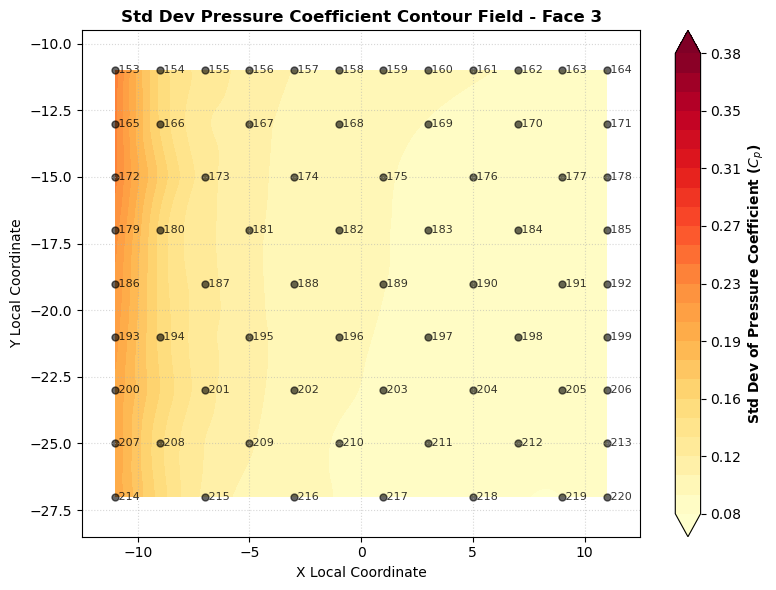

In [41]:
def std_cp_contour(pressure_df, loc_df, face_id):
    """
    Generates a dedicated standard deviation Cp contour plot for one explicitly chosen building face.
    
    Parameters:
    - loc_df: DataFrame containing the raw tap coordinates ('X', 'Y', 'Point_No', 'Face_No')
    - pressure_df: DataFrame containing the time-series wind pressure coefficients
    - face_id: Integer (e.g., 1, 2, 5) targeting the specific face to visualize
    """
    # 1. CHANGE: Calculate the Standard Deviation (std) for each channel instead of the mean
    std_cp_series = pressure_df.std(axis=0)
    std_cp_df = std_cp_series.reset_index()
    std_cp_df.columns = ['Tap no.', 'std_cp']

    # 2. Map the standard deviations back to the coordinates
    total_active_channels = pressure_df.shape[1]
    working_df = loc_df.head(total_active_channels).copy()
    working_df['std_cp'] = std_cp_df['std_cp'].values[:total_active_channels]

    # Get the global min and max Cp across the entire building to keep color scales consistent
    vmin = working_df['std_cp'].min()
    vmax = working_df['std_cp'].max()
    levels = np.linspace(vmin, vmax, 25)

    # 3. Isolate the data specifically for the requested face
    face_data = working_df[working_df['Face_No'] == face_id].copy()
    
    if face_data.empty:
        print(f"❌ Error: Face {face_id} was not found in this dataset or contains no active data channels.")
        return

    # Remove any duplicate tap positions within this face zone
    face_data = face_data.drop_duplicates(subset=['X', 'Y'])
    
    # We need at least 3 unique tap coordinates to calculate a 2D surface field mesh
    if len(face_data) < 3:
        print(f"⚠️ Face {face_id} has only {len(face_data)} unique points. Switching to 'nearest' mapping grid fallback.")
        method_choice = 'nearest'
    else:
        method_choice = 'cubic'

    x = face_data['X'].values
    y = face_data['Y'].values
    z = face_data['std_cp'].values  # CHANGE: Using std values here

    # 4. Handle Flat 1D Profiles (e.g., if a wall face only has one straight row of sensors)
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    
    # Nudge the mesh limits if coordinates are perfectly aligned to prevent QhullError crashes
    if x_min == x_max:
        x_min -= 0.01
        x_max += 0.01
        method_choice = 'nearest'  # Force nearest neighbor if geometrically flat
    if y_min == y_max:
        y_min -= 0.01
        y_max += 0.01
        method_choice = 'nearest'

    # 5. Create a dense coordinate mesh grid for this isolated face
    grid_x, grid_y = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    # 6. Interpolate values locally onto the mesh grid
    try:
        grid_z = griddata((x, y), z, (grid_x, grid_y), method=method_choice)
    except Exception:
        # Emergency absolute backup if triangulation matrices break down
        grid_z = griddata((x, y), z, (grid_x, grid_y), method='nearest')

    # =====================================================================
    # 🎨 RENDER THE TARGET FACE CHART
    # =====================================================================
    plt.figure(figsize=(8, 6))
    
    # CHANGE: Switched cmap to 'YlOrRd' because standard deviation is always positive turbulence
    contour = plt.contourf(grid_x, grid_y, grid_z, levels=levels, cmap='YlOrRd', extend='both')
    
    # Add the colorbar scale (sharing the uniform building bounds)
    cbar = plt.colorbar(contour)
    # CHANGE: Label updated to reflect Standard Deviation
    cbar.set_label('Std Dev of Pressure Coefficient ($C_p$)', fontweight='bold')
    cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    
    # Overlay the exact tap locations as crisp black dots
    plt.scatter(x, y, color='black', s=25, marker='o', alpha=0.6, label='Pressure Taps')
    
    # Add tap labels (Point Number indices)
    for _, row in face_data.iterrows():
        plt.text(row['X'], row['Y'], f" {int(row['Point_No'])}", 
                 color='black', fontsize=8, alpha=0.8, ha='left', va='center')

    # Formatting presentation layers
    # CHANGE: Title updated to reflect Standard Deviation
    plt.title(f"Std Dev Pressure Coefficient Contour Field - Face {face_id}", fontweight='bold', fontsize=12)
    plt.xlabel("X Local Coordinate", fontsize=10)
    plt.ylabel("Y Local Coordinate", fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.5)
    
    # Camera adjustments (Keeps your custom dynamic camera zoom out padding)
    ax = plt.gca()
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    pad_x = 1.5  
    pad_y = 1.5

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)
    
    plt.tight_layout()
    plt.show()

std_cp_contour(pressure_df, loc_df, 3)